# LeetCode #13: Roman to Integer



https://leetcode.com/problems/roman-to-integer/



## Comparison of Approaches



| Approach | Time Complexity | Space Complexity |

| :--- | :--- | :--- |

| **Brute Force: Pair Lookup** | $O(n)$ | $O(1)$ |

| **Optimal: Left-to-Right Lookahead** ★ | $O(n)$ | $O(1)$ |



---



## Understanding the Methods



### Brute Force: Pair Lookup

Build a 13-entry map of every valid symbol (including "IV", "IX", etc.). At each position, check if a 2-character substring matches a subtractive pair first; if so, consume two characters; otherwise consume one. Two comparisons per step.



### Optimal: Left-to-Right Lookahead ★

Use a 7-entry map (single characters only). Scan left to right: if the current character's value is **less than** the next character's value, it is in subtractive position — **subtract** it; otherwise **add** it.



**Why this is better than Pair Lookup:** Same $O(n)$ time and $O(1)$ space, but only one comparison per character and half the map entries. The key insight: in subtractive notation, a smaller value to the **left** of a larger value is always subtracted, so one lookahead check is enough.



**Constraints:**

* `1 <= s.length <= 15`

* `s` contains only the characters `('I', 'V', 'X', 'L', 'C', 'D', 'M')`

* It is guaranteed that `s` is a valid Roman numeral in the range `[1, 3999]`

## Solutions



### C#

In [ ]:
public class Solution {

    public int RomanToInt(string s) {

        var map = new Dictionary<char, int> {

            ['I'] = 1, ['V'] = 5, ['X'] = 10, ['L'] = 50,

            ['C'] = 100, ['D'] = 500, ['M'] = 1000

        };

        int result = 0;

        for (int i = 0; i < s.Length; i++) {

            // Subtract if current value is less than the next (subtractive notation)

            if (i + 1 < s.Length && map[s[i]] < map[s[i + 1]])

                result -= map[s[i]];

            else

                result += map[s[i]];

        }

        return result;

    }

}

### Python

In [ ]:
class Solution:

    def romanToInt(self, s: str) -> int:

        values = {'I': 1, 'V': 5, 'X': 10, 'L': 50,

                  'C': 100, 'D': 500, 'M': 1000}

        result = 0

        for i in range(len(s)):

            # Subtract if current value is less than the next (subtractive notation)

            if i + 1 < len(s) and values[s[i]] < values[s[i + 1]]:

                result -= values[s[i]]

            else:

                result += values[s[i]]

        return result

### Go

In [ ]:
func romanToInt(s string) int {

    values := map[byte]int{

        'I': 1, 'V': 5, 'X': 10, 'L': 50,

        'C': 100, 'D': 500, 'M': 1000,

    }

    result := 0

    for i := 0; i < len(s); i++ {

        // Subtract if current value is less than the next (subtractive notation)

        if i+1 < len(s) && values[s[i]] < values[s[i+1]] {

            result -= values[s[i]]

        } else {

            result += values[s[i]]

        }

    }

    return result

}

### Rust

In [ ]:
impl Solution {

    pub fn roman_to_int(s: String) -> i32 {

        let value = |c: char| match c {

            'I' => 1, 'V' => 5, 'X' => 10, 'L' => 50,

            'C' => 100, 'D' => 500, 'M' => 1000, _ => 0,

        };

        let chars: Vec<char> = s.chars().collect();

        let mut result = 0;

        for i in 0..chars.len() {

            // Subtract if current value is less than the next (subtractive notation)

            if i + 1 < chars.len() && value(chars[i]) < value(chars[i + 1]) {

                result -= value(chars[i]);

            } else {

                result += value(chars[i]);

            }

        }

        result

    }

}

## Example Scenarios



**Example 1 — Common Case**\

**Input:** `s = "III"`\

Three I's in sequence: each is the last character or is followed by an equal-or-smaller value, so all three are added. $1 + 1 + 1 = 3$ → **3**.



**Example 2 — Slightly Complex**\

**Input:** `s = "LVIII"`\

L(50) → no lookahead trigger. V(5) → followed by I(1), not larger, add. Three I's added. No subtractive pairs: $50 + 5 + 1 + 1 + 1 = 58$ → **58**.



**Example 3 — Edge Case: Time Factor**\

**Input:** `s = "MMMDCCCLXXXVIII"`\

The longest valid Roman numeral (15 characters, representing 3888): 15 lookahead comparisons, 15 additions, zero subtractions — maximum iterations with no subtractive pairs → **3888**.



**Example 4 — Edge Case: Space Factor**\

**Input:** `s = "IV"`\

Minimum-length subtractive input (2 characters). I is followed by V(5 > 1), so I is subtracted. V is the last character, so it is added. Only one map, one integer, two iterations: $-1 + 5 = 4$ → **4**.



**Example 5 — Almost-Impossible but Plausible**\

**Input:** `s = "MCMXCIV"`\

1994 encoded: M(+1000) → C(−100, since C < M) → M(+1000) → X(−10, since X < C) → C(+100) → I(−1, since I < V) → V(+5). Three subtractive triggers in a 7-character string. Running total: 1000−100+1000−10+100−1+5 = **1994**.

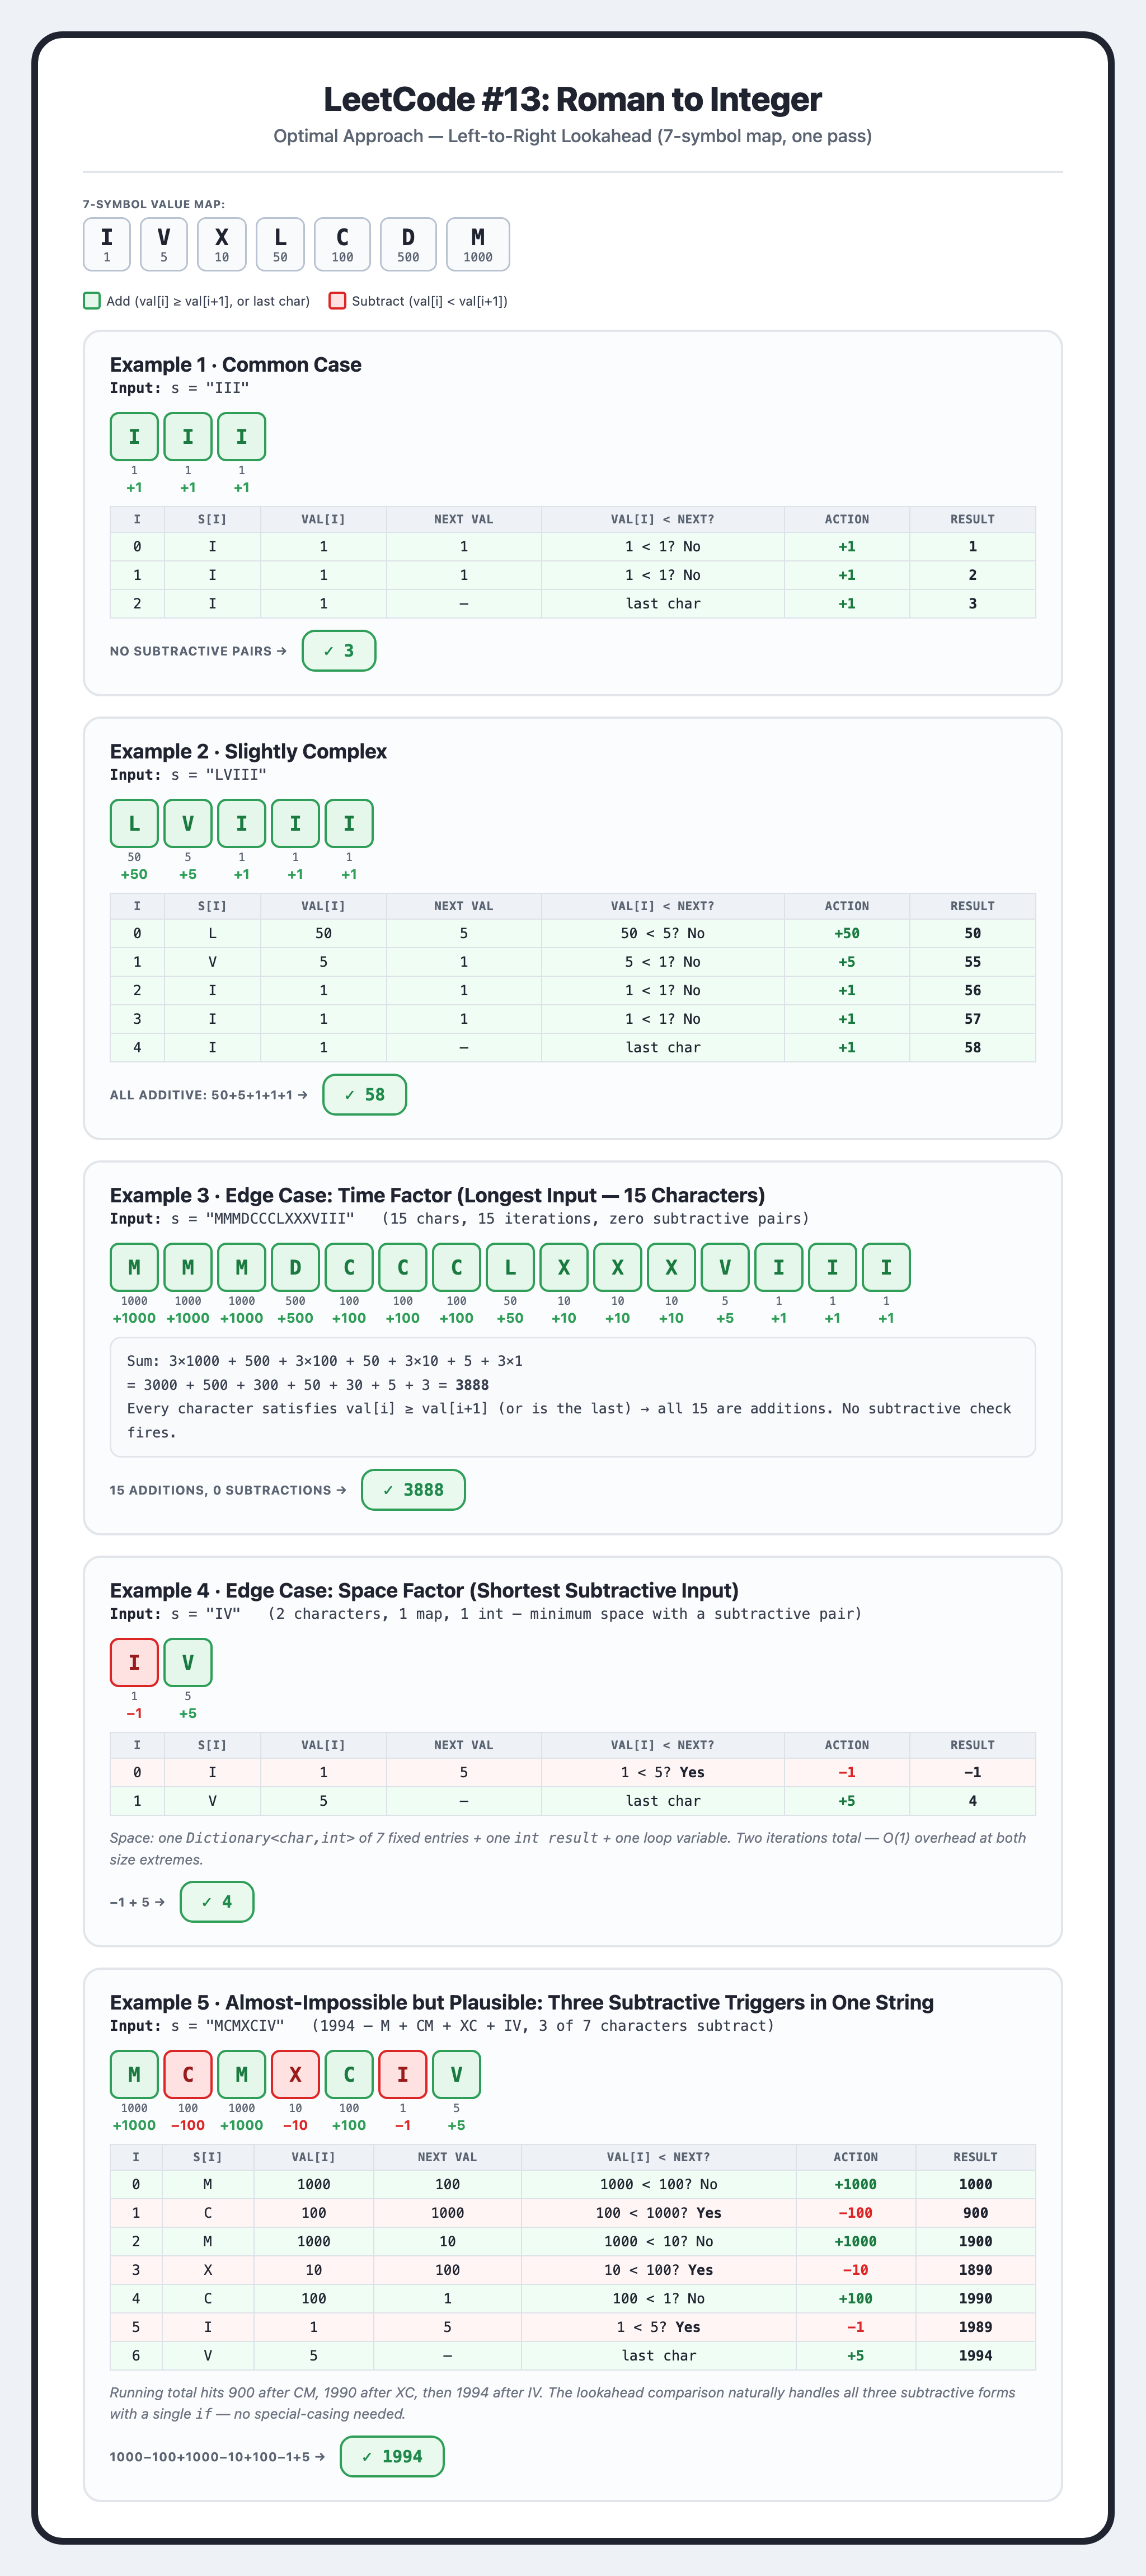